# Peptide LC Retention Time EDA

The dataset gives peptide sequences, optional modifications, and a measured
retention time. The brief is exploratory: understand what the data is, how far
it can be trusted, and what drives retention behaviour.

**Approach.** 
* Understand the data. Get to know the peptides and the measurements themselves, and form a view of what you are actually looking at and how far you would trust it.
* Then take it wherever you find it interesting. You might dig into what actually drives retention behaviour, where the simple picture holds and where it breaks down, or what the data can and cannot tell you. The questions you ask, and what approaches you use, is up to you. We care about how you reason, not about reaching any particular result.

## Load the Data

In [1]:
# Standard library imports
from pathlib import Path

# Data manipulation and analysis
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)  # Opt in to future pandas behavior for downcasting
import numpy as np

# Plotting
from matplotlib import pyplot as plt

# Define the location of the input dataset
input_data_loc = Path("./portal_ds_task/")

# Load the peptide retention dataset into a pandas DataFrame
df = pd.read_csv(input_data_loc / "peptide_retention.csv")


In [2]:
df.columns

Index(['ID', 'PeptideSequence', 'Modifications', 'RetentionTime'], dtype='object')

In [3]:
df

,ID,PeptideSequence,Modifications,RetentionTime
0,66442,EELNAISGPNEFAEFYDR,NaN,76.808103
1,9346,VPAQSESVR,NaN,-35.365414
2,87137,SEPEDPVTER,NaN,-12.258285
3,31419,SIRPGLSPYR,NaN,-0.953151
4,93265,NLINEMLTINPAK,NaN,88.572770
...,...,...,...,...
9995,43305,LCNSLEESIR,NaN,18.683235
9996,17792,RPFGVAVMDITDIIHGK,NaN,80.462639
9997,16249,LRPQTYDLQESNVQLK,NaN,24.938680
9998,101011,LPPVLSHPIFDDR,NaN,57.474966


## What am I looking at?

We first look at the shape, types and missingness of the data. One decision worth stating: the modifications
column is blank for 92% of rows, but that is meaningful absence rather than missing
data. A blank means the peptide carries no modification, which is a fact about the
molecule, so there is nothing to impute. Treating it as missing and filling it would be
a mistake.

A quick check of the non-blank values shows two modification types, oxidation and
acetylation, both of which are known post-translational modifications that change a
peptide's chemistry.

In [4]:
# Display the number of rows and columns in the dataset
print(df.shape)

# Show the data type of each column
print(df.dtypes)

# Count missing (NaN) values in each column
print(df.isna().sum())

# Display the number of unique values in each column
print(df.nunique())

# Display the unique values in the 'Modifications' column
# This helps identify the different peptide modifications present
print("\nUnique modifications:")
print(df["Modifications"].unique())

# Display the frequency of each modification
# Useful for understanding how common each modification is
print("\nModification counts:")
print(df["Modifications"].value_counts())


(10000, 4)
ID                   int64
PeptideSequence     object
Modifications       object
RetentionTime      float64
dtype: object
ID                    0
PeptideSequence       0
Modifications      9175
RetentionTime         0
dtype: int64
ID                 10000
PeptideSequence     9936
Modifications         48
RetentionTime       9996
dtype: int64

Unique modifications:
[nan '1|Acetyl' '4|Oxidation' '10|Oxidation' '6|Oxidation' '2|Oxidation'
 '8|Oxidation' '7|Oxidation' '13|Oxidation' '9|Oxidation' '1|Oxidation'
 '3|Oxidation' '16|Oxidation' '15|Oxidation' '14|Oxidation' '11|Oxidation'
 '29|Oxidation' '5|Oxidation' '30|Oxidation' '19|Oxidation' '12|Oxidation'
 '20|Oxidation' '27|Oxidation' '23|Oxidation' '18|Oxidation'
 '24|Oxidation' '25|Oxidation' '21|Oxidation' '17|Oxidation'
 '22|Oxidation' '4|Oxidation|13|Oxidation' '2|Oxidation|3|Oxidation'
 '1|Oxidation|2|Oxidation' '3|Oxidation|11|Oxidation'
 '1|Oxidation|6|Oxidation' '36|Oxidation' '2|Oxidation|9|Oxidation'
 '10|Oxidation

## Interrogate the target before trusting it

Retention time is a duration, so it cannot be negative. If any values are, this column
is not raw retention time.

I look at the distribution shape to understand the scope of the data, its modality and that it is most likely a transformed version of RT.

count    10000.000000
mean        43.962328
std         46.414624
min       -131.607569
25%         10.709574
50%         44.089721
75%         76.710009
max        147.746952
Name: RetentionTime, dtype: float64
negative fraction: 0.1918
skew: 0.02659454955984972


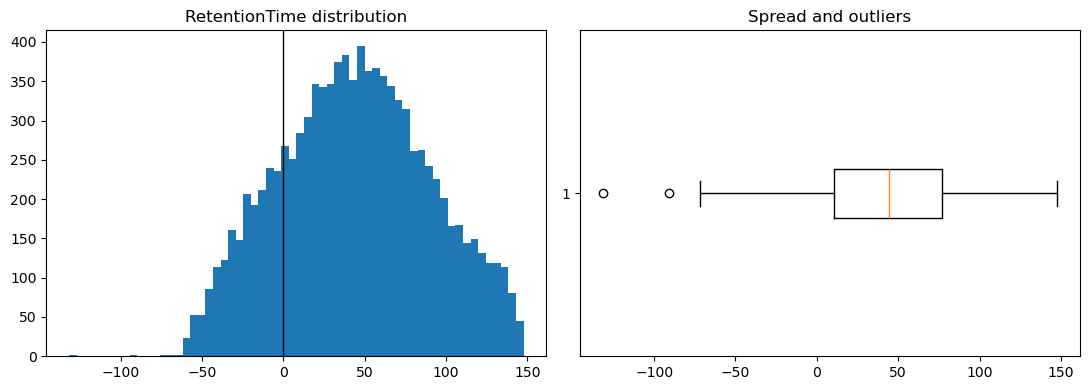

In [5]:
# Extract the target variable (retention time) from the dataset
rt = df["RetentionTime"]

# Display summary statistics (count, mean, std, min, quartiles, max)
print(rt.describe())

# Calculate the proportion of negative retention time values
print("negative fraction:", (rt < 0).mean())

# Measure the skewness of the distribution
# Values close to 0 indicate a symmetric distribution,
# while positive/negative values indicate right/left skew.
print("skew:", rt.skew())

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# Plot a histogram to visualize the distribution of retention times
ax[0].hist(rt, bins=60)

# Add a vertical line at zero for reference
ax[0].axvline(0, color="k", lw=1)

# Add a title to the histogram
ax[0].set_title("RetentionTime distribution")

# Plot a horizontal boxplot to show spread and potential outliers
ax[1].boxplot(rt, vert=False)

# Add a title to the boxplot
ax[1].set_title("Spread and outliers")

# Adjust subplot spacing for a cleaner layout
plt.tight_layout()

# Display the plots
plt.show()


**Finding.** About 19% of values are negative, and the distribution is symmetric
(skew 0.03) but centred near +44, not zero, with mean and median almost identical. My understanding is that it is a shifted or rescaled version of the data, which is why it can have negative values.

## Are these real peptides?

Understanding the molecules. Two checks: does any
peptide have repeated amino acids, which would suggest artificially generated data, and
does overall amino acid usage match typical proteomic abundance (real biology) or sit
flat near 1/20 (randomly generated)?

length min/max: 7 40
count    10000.0
mean        14.8
std          6.2
min          7.0
25%         10.0
50%         13.0
75%         18.0
max         40.0
Name: length, dtype: float64

peptides >=75% one amino acid: 0
[]

overall AA frequency: {'L': 0.106, 'E': 0.096, 'A': 0.078, 'S': 0.071, 'V': 0.068, 'G': 0.063, 'D': 0.061, 'P': 0.054, 'T': 0.053, 'I': 0.051, 'K': 0.051, 'Q': 0.046, 'R': 0.038, 'N': 0.037, 'F': 0.036, 'Y': 0.026, 'H': 0.024, 'M': 0.018, 'C': 0.014, 'W': 0.009}


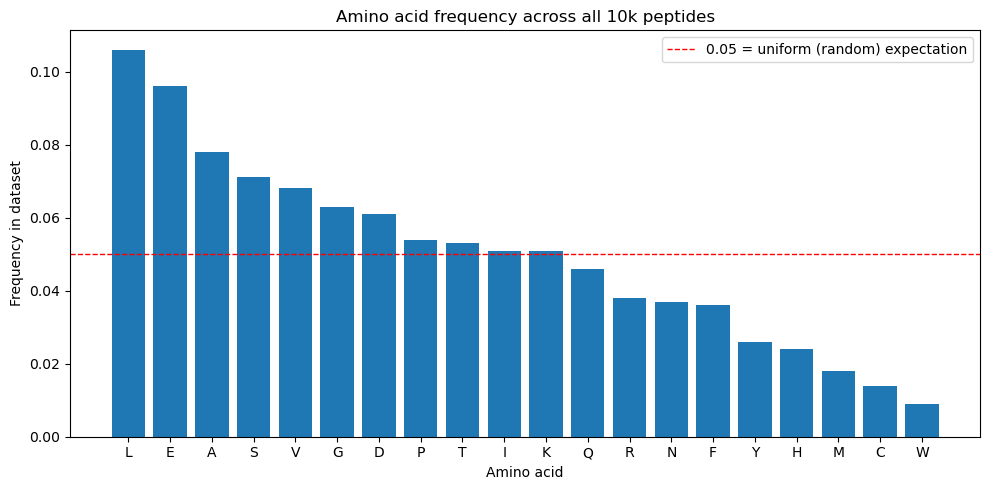

In [6]:
# Calculate the length of each peptide sequence
df["length"] = df["PeptideSequence"].str.len()

# Display the minimum and maximum peptide lengths
print("length min/max:", df["length"].min(), df["length"].max())

# Show descriptive statistics for peptide lengths
print(df["length"].describe().round(1))


# Check whether any peptide is dominated by a single amino acid
# (i.e., one amino acid makes up at least 75% of the sequence)
def max_frac(seq):
    return max(seq.count(a) for a in set(seq)) / len(seq)

# Compute the maximum amino acid fraction for each peptide
df["max_aa_frac"] = df["PeptideSequence"].apply(max_frac)

# Count highly repetitive peptides
print("\npeptides >=75% one amino acid:", (df["max_aa_frac"] >= 0.75).sum())

# Display a few examples of highly repetitive peptides
print(df.loc[df["max_aa_frac"] >= 0.75, "PeptideSequence"].head(10).tolist())


# Calculate the overall amino acid frequency across all peptide sequences
from collections import Counter

allaa = Counter("".join(df["PeptideSequence"]))
total = sum(allaa.values())

# Compute the relative frequency of each standard amino acid
freq = {a: round(allaa[a] / total, 3) for a in "ACDEFGHIKLMNPQRSTVWY"}
print("\noverall AA frequency:", dict(sorted(freq.items(), key=lambda x: -x[1])))

# Sort frequencies from most to least common for plotting
freq_sorted = dict(sorted(freq.items(), key=lambda x: -x[1]))

# Create a bar chart of amino acid frequencies
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(freq_sorted.keys(), freq_sorted.values())

# Label the axes and title
ax.set_xlabel("Amino acid")
ax.set_ylabel("Frequency in dataset")
ax.set_title("Amino acid frequency across all 10k peptides")

# Add a reference line showing the expected frequency under a uniform distribution
ax.axhline(
    0.05,
    color="red",
    lw=1,
    ls="--",
    label="0.05 = uniform (random) expectation"
)

# Display the legend and plot
ax.legend()
plt.tight_layout()
plt.show()


The peptides look real, but they also look very tidy. Almost no common sequences,
no obvious junk, few extreme outliers, and amino-acid freq that looks like natural abundance. That cleanliness is worth being suspicious of rather than
reassured by: raw output is rarely well behaved, which suggests
the data has already been filtered or curated before it reached me. That does not
make it untrustworthy, but it does mean I am looking at a processed view.

## How far can I trust it?

Two checks. Are there exact re-measurements, same sequence and same modification? And does the ID column carry any structure?

In [7]:
# Check for repeated measurements of the same peptide and modification
print("=== Exact re-measurements ===")

df_check = df.copy()
df_check["Modifications"] = df_check["Modifications"].fillna("NONE")

groups = (
    df_check
    .groupby(["PeptideSequence", "Modifications"])["RetentionTime"]
)

# Number of observations per peptide-modification combination
counts = groups.size()
duplicates = counts[counts > 1]

print(f"Duplicate peptide-modification pairs: {len(duplicates)}")

if not duplicates.empty:
    print("\nExamples:")
    print(duplicates.head(10))

    # Retention time variation between repeat measurements
    rt_spread = groups.agg(lambda x: x.max() - x.min()).loc[duplicates.index]

    print("\nRetention time spread across duplicate measurements:")
    print(rt_spread.describe())


# Examine the ID column
print("\n=== ID column ===")
print(f"Unique IDs: {df['ID'].nunique()} / {len(df)}")
print(f"Range: {df['ID'].min()} - {df['ID'].max()}")
print(f"Data type: {df['ID'].dtype}")

print("\nSummary statistics:")
print(df["ID"].describe())

=== Exact re-measurements ===
Duplicate peptide-modification pairs: 0

=== ID column ===
Unique IDs: 10000 / 10000
Range: 2 - 113159
Data type: int64

Summary statistics:
count     10000.000000
mean      56241.349900
std       32857.783193
min           2.000000
25%       27632.750000
50%       56120.000000
75%       84700.000000
max      113159.000000
Name: ID, dtype: float64


**Findings.** Zero exact re-measurements exist, so measurement noise cannot be
tested from this data.

The ID runs from 2 to 113,159 across only 10,000 unsorted rows, so this is a shuffled
subsample of a larger set.

## What drives retention?

Sections above established what the data is and how far to trust it. From here I look
at what actually drives retention.

The first thing worth checking was which modification is actually present enough to say
anything about. I classified every modification string into a type, oxidation (single or
multiple), acetyl, or none, and found oxidation dominates. That decided
where to look next: whatever I can say about modification effects will be about
oxidation, because the other types will not have enough data to support a claim.

I then looked specifically at the oxidation cases and checked whether each modified
peptide had a matching unmodified version of the same sequence. Where there was, I
compared the two directly and see how the addition of the modification affected
retention, with the peptide itself held constant.

In [8]:
# Categorise peptide modifications
def mod_type(mod):
    if pd.isna(mod):
        return "none"
    if "Acetyl" in mod:
        return "acetyl"

    ox_count = mod.count("Oxidation")
    if ox_count == 1:
        return "ox1"
    elif ox_count >= 2:
        return "ox2+"
    else:
        return "other"


# Compare modified peptides with their unmodified counterpart
pairs = []

duplicated = df[df["PeptideSequence"].duplicated(keep=False)]

for sequence, group in duplicated.groupby("PeptideSequence"):

    group = group.copy()
    group["mtype"] = group["Modifications"].apply(mod_type)

    # Skip sequences without an unmodified peptide
    if "none" not in group["mtype"].values:
        continue

    # Use the unmodified peptide as the baseline
    baseline = group.loc[group["mtype"] == "none", "RetentionTime"].mean()

    # Calculate the retention time shift for each modified peptide
    modified = group[group["mtype"] != "none"]

    for _, row in modified.iterrows():
        pairs.append({
            "PeptideSequence": sequence,
            "Modification": row["mtype"],
            "DeltaRT": row["RetentionTime"] - baseline
        })

pairs = pd.DataFrame(pairs)

# Summarise the effect of each modification type
summary = (
    pairs
    .groupby("Modification")["DeltaRT"]
    .agg(["count", "median", "mean"])
)

print(summary)


              count     median       mean
Modification                             
acetyl            2  26.381698  26.381698
ox1              55 -13.505584 -14.814977
ox2+              2 -35.387268 -35.387268


In [9]:
# Identify peptide sequences that appear more than once
duplicate_sequences = df[df["PeptideSequence"].duplicated(keep=False)]
duplicate_sequences = duplicate_sequences.sort_values("PeptideSequence")

# Display a summary of repeated sequences
print(f"Rows involved in repeats: {len(duplicate_sequences)}")
print(f"Distinct repeated sequences: {duplicate_sequences['PeptideSequence'].nunique()}\n")

# Display each repeated sequence with its modifications and retention times
for sequence, group in duplicate_sequences.groupby("PeptideSequence"):

    modifications = group["Modifications"].fillna("None").tolist()
    retention_times = group["RetentionTime"].round(2).tolist()

    print(
        f"{sequence:22s} "
        f"n={len(group):2d}  "
        f"Modifications={modifications}  "
        f"RetentionTime={retention_times}"
    )


Rows involved in repeats: 127
Distinct repeated sequences: 63

AAAMVPGR               n= 2  Modifications=['1|Acetyl', '4|Oxidation']  RetentionTime=[25.36, 0.82]
AAAVPVEFQEHHLSEVQNMASEEKLEQVLSSMK n= 2  Modifications=['19|Oxidation', 'None']  RetentionTime=[70.66, 79.46]
ADLEMEIENLK            n= 2  Modifications=['5|Oxidation', 'None']  RetentionTime=[60.88, 62.57]
ADQIETQQLMR            n= 2  Modifications=['None', '10|Oxidation']  RetentionTime=[19.24, -0.85]
AFAMIIDKLEEDINSSMTDSTAASRPPVTLR n= 2  Modifications=['None', '4|Oxidation']  RetentionTime=[113.54, 112.06]
ASFITPVPGGVGPMTVAMLMQSTVESAK n= 2  Modifications=['None', '14|Oxidation']  RetentionTime=[138.41, 135.16]
DAWQMTEEEYTPPAGAK      n= 2  Modifications=['5|Oxidation', 'None']  RetentionTime=[38.26, 49.44]
DELHIVEAEAMNYEGSPIK    n= 2  Modifications=['11|Oxidation', 'None']  RetentionTime=[64.71, 74.16]
DSYCSYMGHFDLLNYFAIAENESK n= 2  Modifications=['None', '7|Oxidation']  RetentionTime=[125.18, 111.72]
EAEAMALLAEAER          

### Isolating the clean comparison

Some repeated sequences carry double oxidation, acetyl, or mixed modification states,
which are different comparisons. To isolate the effect of a single oxidation, I keep only
sequences with exactly one unmodified and one singly-oxidised member, and take the
difference within each pair (oxidised minus unmodified). This is a paired design: each
peptide is compared to itself, and removing the risk of other variables affecting results

Clean unmodified vs single oxidation pairs: 53
count    53.000000
mean    -14.257556
std       7.259117
min     -36.995521
25%     -19.154388
50%     -13.463331
75%     -10.652084
max      -0.090863
Name: Delta_RT, dtype: float64


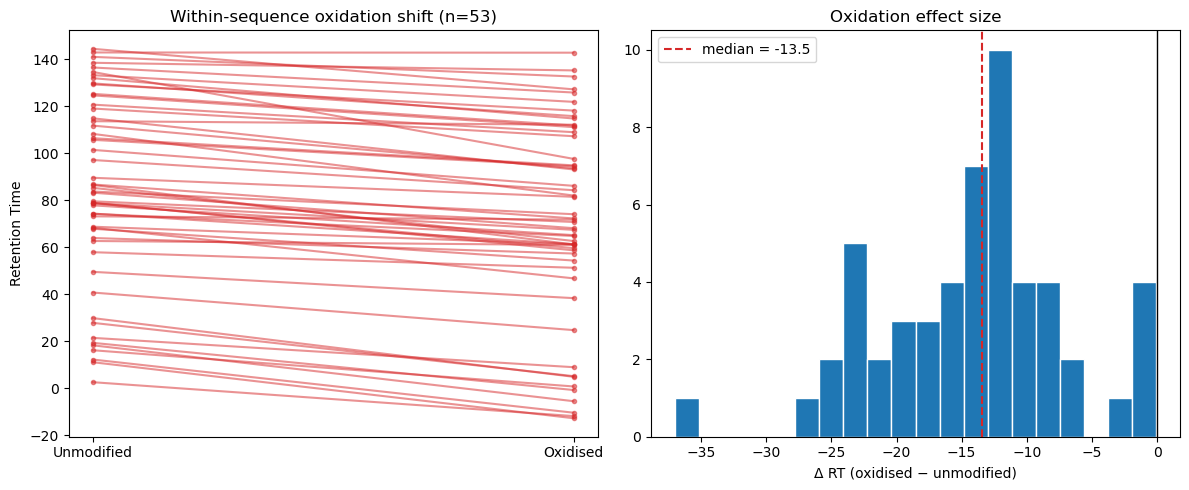

Shapiro-Wilk: ShapiroResult(statistic=np.float64(0.969660972814109), pvalue=np.float64(0.19513969822191818))
Skew: -0.44
Wilcoxon: WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(2.386484752546066e-10))
n=53, mean=-14.26, median=-13.46
t=-14.30, p=1.18e-19, 95% CI=[-16.3, -12.3]


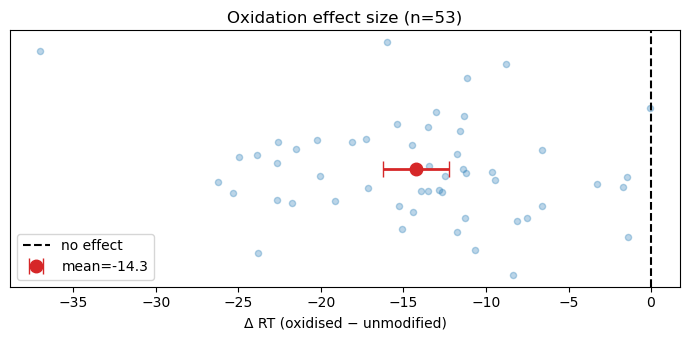

In [10]:
import matplotlib.pyplot as plt
from scipy import stats


# -------------------------------------------------------
# Build matched unmodified vs single-oxidation pairs
# -------------------------------------------------------

pairs = []

# Only examine peptide sequences appearing more than once
repeated = df[df["PeptideSequence"].duplicated(keep=False)]

for sequence, group in repeated.groupby("PeptideSequence"):

    group = group.copy()
    group["ModificationType"] = group["Modifications"].apply(mod_type)

    # Keep only peptides with exactly one unmodified and one oxidised measurement
    if set(group["ModificationType"]) == {"none", "ox1"} and len(group) == 2:

        unmodified_rt = group.loc[
            group["ModificationType"] == "none",
            "RetentionTime"
        ].iloc[0]

        oxidised_rt = group.loc[
            group["ModificationType"] == "ox1",
            "RetentionTime"
        ].iloc[0]

        pairs.append({
            "Sequence": sequence,
            "Unmodified_RT": unmodified_rt,
            "Oxidised_RT": oxidised_rt,
            "Delta_RT": oxidised_rt - unmodified_rt
        })


pairs = pd.DataFrame(pairs)

deltas = pairs["Delta_RT"]

print(f"Clean unmodified vs single oxidation pairs: {len(pairs)}")
print(deltas.describe())


# -------------------------------------------------------
# Visualise paired retention-time shifts
# -------------------------------------------------------

fig, ax = plt.subplots(1, 2, figsize=(12, 5))


# Paired slope plot
for _, row in pairs.iterrows():

    colour = "tab:red" if row["Delta_RT"] < 0 else "tab:grey"

    ax[0].plot(
        [0, 1],
        [row["Unmodified_RT"], row["Oxidised_RT"]],
        color=colour,
        alpha=0.5,
        marker="o",
        ms=3
    )

ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(["Unmodified", "Oxidised"])
ax[0].set_ylabel("Retention Time")
ax[0].set_title(f"Within-sequence oxidation shift (n={len(pairs)})")


# Distribution of RT changes
ax[1].hist(
    deltas,
    bins=20,
    color="tab:blue",
    edgecolor="white"
)

ax[1].axvline(0, color="black", lw=1)
ax[1].axvline(
    deltas.median(),
    color="tab:red",
    ls="--",
    lw=1.5,
    label=f"median = {deltas.median():.1f}"
)

ax[1].set_xlabel("Δ RT (oxidised − unmodified)")
ax[1].set_title("Oxidation effect size")
ax[1].legend()

plt.tight_layout()
plt.show()


# -------------------------------------------------------
# Statistical testing
# -------------------------------------------------------

# Normality check
shapiro = stats.shapiro(deltas)

# One-sample t-test against no retention-time change
t_stat, p_value = stats.ttest_1samp(deltas, 0)

# 95% confidence interval of mean shift
confidence_interval = stats.t.interval(
    0.95,
    len(deltas) - 1,
    loc=deltas.mean(),
    scale=stats.sem(deltas)
)

# Non-parametric paired test
wilcoxon = stats.wilcoxon(deltas)


print(f"Shapiro-Wilk: {shapiro}")
print(f"Skew: {deltas.skew():.2f}")
print(f"Wilcoxon: {wilcoxon}")
print(
    f"n={len(deltas)}, "
    f"mean={deltas.mean():.2f}, "
    f"median={deltas.median():.2f}"
)
print(
    f"t={t_stat:.2f}, "
    f"p={p_value:.2e}, "
    f"95% CI=[{confidence_interval[0]:.1f}, {confidence_interval[1]:.1f}]"
)


# -------------------------------------------------------
# Effect size plot
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 3.5))

# Show individual peptide shifts
ax.scatter(
    deltas,
    np.random.normal(0, 0.04, len(deltas)),
    alpha=0.3,
    color="tab:blue",
    s=20
)

# Show mean estimate and confidence interval
ax.errorbar(
    deltas.mean(),
    0,
    xerr=[
        [deltas.mean() - confidence_interval[0]],
        [confidence_interval[1] - deltas.mean()]
    ],
    fmt="o",
    color="tab:red",
    markersize=9,
    capsize=6,
    lw=2,
    label=f"mean={deltas.mean():.1f}"
)

ax.axvline(0, color="black", ls="--", label="no effect")

ax.set_yticks([])
ax.set_xlabel("Δ RT (oxidised − unmodified)")
ax.set_title(f"Oxidation effect size (n={len(deltas)})")
ax.legend()

plt.tight_layout()
plt.show()

**Reading the plots.** Every one of the 53 lines in the left panel slopes downward, no
exceptions: oxidation consistently lowers retention time. The right panel shows the size
of that shift across pairs, centred around -13 to -14 with a spread from near zero to
about -37, rather than a single fixed value. That spread suggests the effect size depends
on the peptide, which is what we explore now.

A one-sample paired t-test then showed us that there is a significant difference (95% CI = [-16.3, -12.3]), and modifications have a real effect on RT. I also checked for normality so the assumptions of a parametric test are met.

Next, I dug into what else could effect RT.

Intuitively, longer peptides should retain longer, more amino acids interacting with the column. Testing
whether that holds and how much it explains.

Unmodified peptides: 9175
count    9175.000000
mean       14.647738
std         6.063373
min         7.000000
25%        10.000000
50%        13.000000
75%        18.000000
max        40.000000
Name: Length, dtype: float64


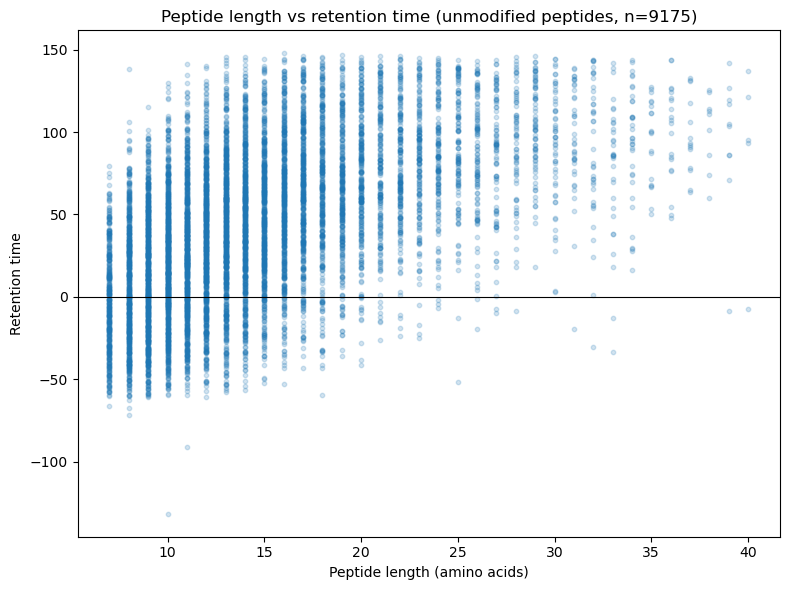

Pearson correlation: 0.550


In [11]:
# -------------------------------------------------------
# Relationship between peptide length and retention time
# using unmodified peptides only
# -------------------------------------------------------

# Select peptides without modifications
unmodified = df[df["Modifications"].isna()].copy()

# Calculate peptide length (number of amino acids)
unmodified["Length"] = unmodified["PeptideSequence"].str.len()

# Summarise peptide length distribution
print(f"Unmodified peptides: {len(unmodified)}")
print(unmodified["Length"].describe())


# -------------------------------------------------------
# Plot peptide length against retention time
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    unmodified["Length"],
    unmodified["RetentionTime"],
    alpha=0.2,
    s=10
)

ax.set_xlabel("Peptide length (amino acids)")
ax.set_ylabel("Retention time")
ax.set_title(
    f"Peptide length vs retention time (unmodified peptides, n={len(unmodified)})"
)

# Reference line at zero retention time
ax.axhline(0, color="black", lw=0.8)

plt.tight_layout()
plt.show()


# -------------------------------------------------------
# Quantify linear association
# -------------------------------------------------------

correlation = unmodified["Length"].corr(unmodified["RetentionTime"])

print(f"Pearson correlation: {correlation:.3f}")


**Finding.** Length correlates only moderately with retention (r = 0.55, about 30% of
variance), and the shape of the relationship matters more than the coefficient. It is not
a uniform rise: the minimum RT increases with length, while the top
stays roughly flat, so at any fixed length retention still spans the full range of
the dataset.

That raises the obvious question: what else is riding along with length? Every extra
amino acid is also extra amino acid composition, so part of what looks like a length effect
could really be composition in disguise. That is what I test next.

##  Amino acid composition

My idea was, for each amino acid, does a higher fraction of it go with higher retention? Fractions
rather than raw counts, as counts would re-measure length through twenty since a longer peptide has more of everything. 

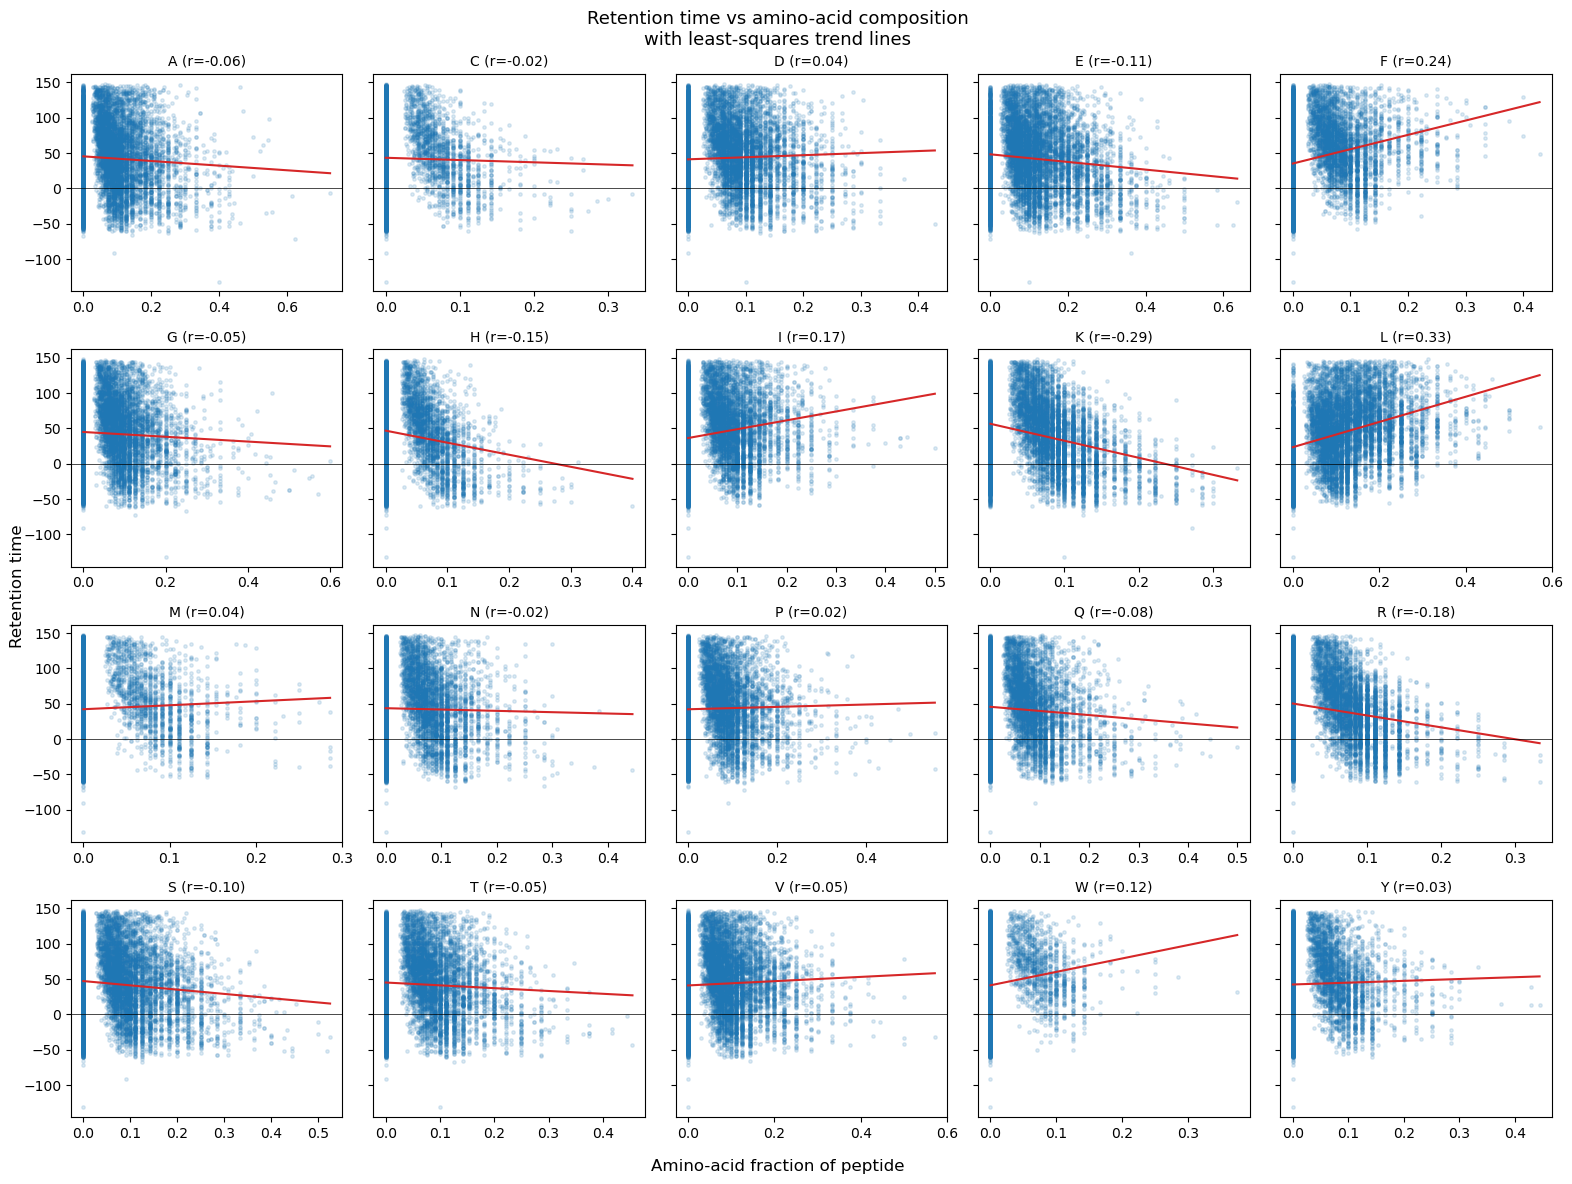

In [12]:
# -------------------------------------------------------
# Relationship between amino-acid composition and retention time
# using unmodified peptides only
# -------------------------------------------------------

amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

# Select unmodified peptides
unmodified = df[df["Modifications"].isna()].copy()

# Calculate the fraction of each amino acid within each peptide
for aa in amino_acids:
    unmodified[aa] = unmodified["PeptideSequence"].apply(
        lambda seq: seq.count(aa) / len(seq)
    )


# -------------------------------------------------------
# Plot retention time against amino-acid composition
# -------------------------------------------------------

fig, axes = plt.subplots(
    4,
    5,
    figsize=(16, 12),
    sharey=True
)

for ax, aa in zip(axes.flat, amino_acids):

    x = unmodified[aa].values
    y = unmodified["RetentionTime"].values

    # Scatter plot of amino-acid fraction vs retention time
    ax.scatter(
        x,
        y,
        alpha=0.15,
        s=6
    )

    # Fit a simple linear regression line
    slope, intercept = np.polyfit(x, y, 1)

    x_line = np.array([x.min(), x.max()])
    ax.plot(
        x_line,
        slope * x_line + intercept,
        color="tab:red",
        lw=1.5
    )

    # Calculate Pearson correlation coefficient
    correlation = np.corrcoef(x, y)[0, 1]

    ax.set_title(
        f"{aa} (r={correlation:.2f})",
        fontsize=10
    )

    # Reference line for zero retention time
    ax.axhline(
        0,
        color="black",
        lw=0.5
    )


# Shared labels and title
fig.supxlabel("Amino-acid fraction of peptide")
fig.supylabel("Retention time")
fig.suptitle(
    "Retention time vs amino-acid composition\n"
    "with least-squares trend lines",
    fontsize=13
)

plt.tight_layout()
plt.show()

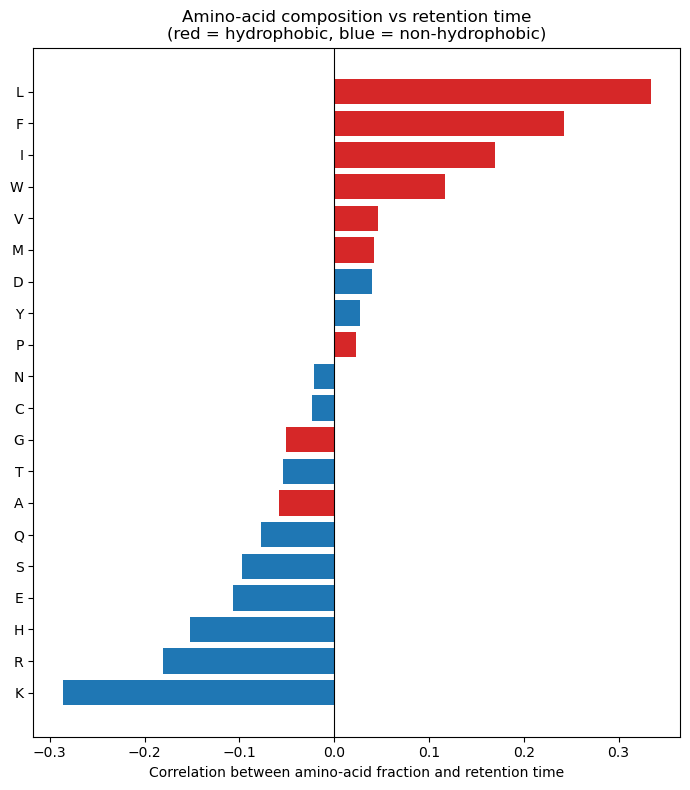

In [13]:
# -------------------------------------------------------
# Compare amino-acid composition with retention time
# Grouping amino acid by hydrophobicity
# -------------------------------------------------------

# Define hydrophobic amino acids
hydrophobic = set("AGILMFPWV")

# Calculate Pearson correlation between each amino-acid fraction and RT
aa_correlations = (
    unmodified[amino_acids]
    .corrwith(unmodified["RetentionTime"])
    .sort_values()
)

# Colour hydrophobic amino acid differently from other amino acid
bar_colors = [
    "tab:red" if aa in hydrophobic else "tab:blue"
    for aa in aa_correlations.index
]


# -------------------------------------------------------
# Plot correlation values
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 8))

ax.barh(
    aa_correlations.index,
    aa_correlations.values,
    color=bar_colors
)

# Reference line showing no correlation
ax.axvline(
    0,
    color="black",
    lw=0.8
)

ax.set_xlabel("Correlation between amino-acid fraction and retention time")
ax.set_title(
    "Amino-acid composition vs retention time\n"
    "(red = hydrophobic, blue = non-hydrophobic)"
)

plt.tight_layout()
plt.show()

### Composition, per amino acid

The grid shows retention plotted against each amino acid's fraction of the peptide, one
panel per amino acid, with a least-squares line and its correlation. Reading it: L, F, I and W show a clear upward tilt, more of that amino acid goes with higher
retention. K, R, H and E show a clear downward tilt. Most others sit close to flat.

Sorting all twenty by correlation makes the pattern easier to read in one view than
scanning twenty panels. The amino acids fall into a clean order from strongly
retention-increasing to strongly retention-decreasing, and that order is what I check
against a real hydrophobic/hydrophilic classification next.

### Does the order match known hydrophobicity?

The brief points to hydrophobicity as the established driver of retention, so I compared
the ordering against a standard hydrophobic/hydrophilic classification
([BOC Sciences](https://aapep.bocsci.com/resources/hydrophobic-and-hydrophilic-amino-acids.html)),
coloured red for hydrophobic and blue for hydrophilic.

The two mostly agree: the top of the chart (L, F, I, W, V, M) is hydrophobic, the bottom
(K, R, H, E) is hydrophilic. But two amino acids sit on the wrong side. Glycine and alanine
are classified hydrophobic yet correlate negatively with retention here.

Correlation between fitted coefficients and Meek scale: 0.670

   ridge_coefficient  meek_coefficient
E               0.40              -7.5
R             -29.16              -4.5
S              -4.32              -3.7
K             -32.21              -3.2
D               1.99              -2.8
Q              -3.79              -2.5
C              -1.86              -2.2
N              -3.24              -1.6
G              -3.68              -0.5
A              -0.97              -0.1
H             -10.61               0.8
T              -1.50               1.5
V               6.69               3.3
M               4.00               7.1
P               3.26               8.0
Y               4.65               8.2
L              20.26              10.0
I              12.85              11.8
F              15.67              13.9
W               8.56              18.1


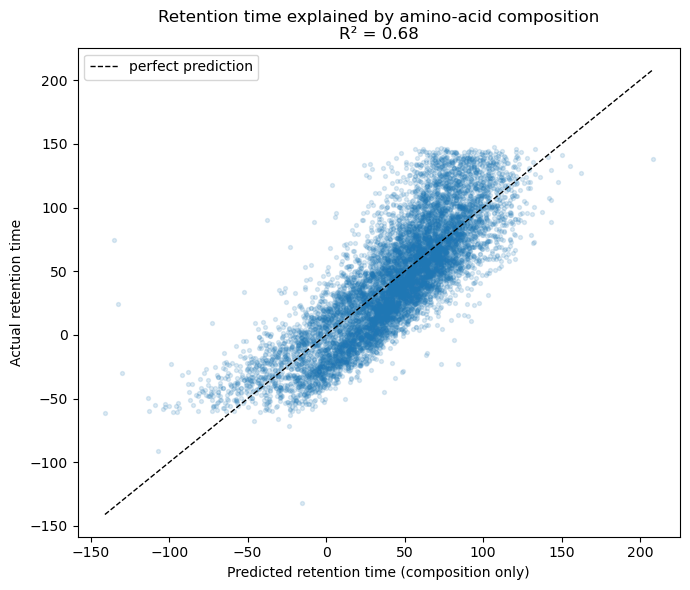

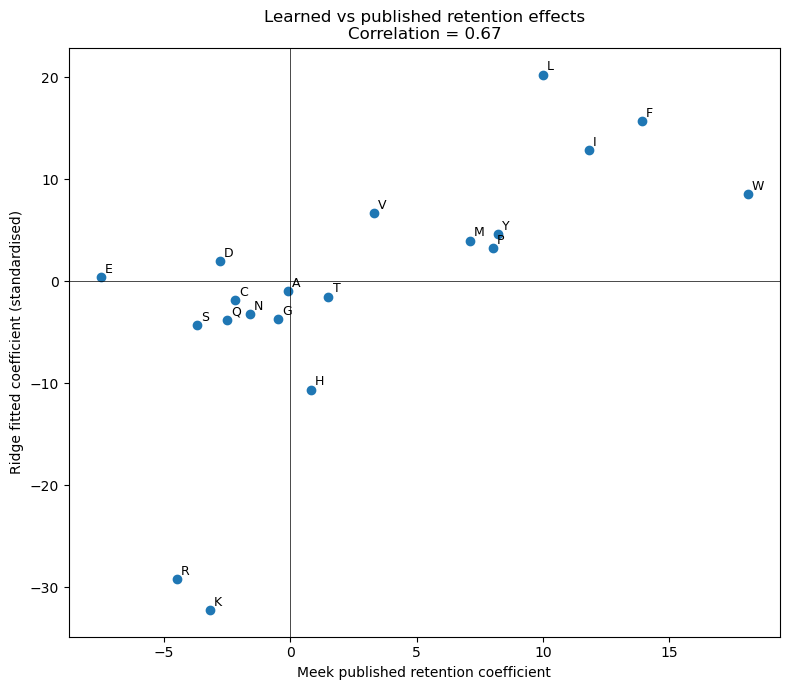

In [14]:
# -------------------------------------------------------
# Compare learned amino-acid retention effects with
# published HPLC retention coefficients (Meek 1980)
# -------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler


# Published amino-acid retention coefficients
# (Meek HPLC hydrophobicity scale)
meek_coefficients = pd.Series({
    "A": -0.1,
    "R": -4.5,
    "N": -1.6,
    "D": -2.8,
    "C": -2.2,
    "Q": -2.5,
    "E": -7.5,
    "G": -0.5,
    "H": 0.8,
    "I": 11.8,
    "L": 10.0,
    "K": -3.2,
    "M": 7.1,
    "F": 13.9,
    "P": 8.0,
    "S": -3.7,
    "T": 1.5,
    "W": 18.1,
    "Y": 8.2,
    "V": 3.3
})


# -------------------------------------------------------
# Build amino-acid composition features
# -------------------------------------------------------

amino_acids = list("ACDEFGHIKLMNPQRSTVWY")

unmodified = df[df["Modifications"].isna()].copy()

for aa in amino_acids:
    unmodified[aa] = unmodified["PeptideSequence"].apply(
        lambda seq: seq.count(aa) / len(seq)
    )


X = unmodified[amino_acids]
y = unmodified["RetentionTime"]


# -------------------------------------------------------
# Ridge regression
# Standardisation reduces issues caused by correlated
# amino-acid composition features
# -------------------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

model = Ridge(alpha=1.0)
model.fit(X_scaled, y)


# Learned amino-acid effects
ridge_coefficients = pd.Series(
    model.coef_,
    index=amino_acids
)


# Compare fitted coefficients with published values
comparison = pd.DataFrame({
    "ridge_coefficient": ridge_coefficients,
    "meek_coefficient": meek_coefficients
}).dropna()


correlation = comparison["ridge_coefficient"].corr(
    comparison["meek_coefficient"]
)

print(
    f"Correlation between fitted coefficients and Meek scale: "
    f"{correlation:.3f}\n"
)

print(comparison.sort_values("meek_coefficient").round(2))


# -------------------------------------------------------
# Evaluate how much composition alone explains RT
# -------------------------------------------------------

unmodified["Predicted_RT"] = model.predict(X_scaled)

r_squared = model.score(X_scaled, y)


fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    unmodified["Predicted_RT"],
    unmodified["RetentionTime"],
    alpha=0.15,
    s=8
)

limits = [
    min(unmodified["Predicted_RT"].min(), y.min()),
    max(unmodified["Predicted_RT"].max(), y.max())
]

ax.plot(
    limits,
    limits,
    "k--",
    lw=1,
    label="perfect prediction"
)

ax.set_xlabel("Predicted retention time (composition only)")
ax.set_ylabel("Actual retention time")
ax.set_title(
    f"Retention time explained by amino-acid composition\n"
    f"R² = {r_squared:.2f}"
)

ax.legend()
plt.tight_layout()
plt.show()


# -------------------------------------------------------
# Compare fitted coefficients against Meek coefficients
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(
    comparison["meek_coefficient"],
    comparison["ridge_coefficient"]
)

for aa, row in comparison.iterrows():
    ax.annotate(
        aa,
        (
            row["meek_coefficient"],
            row["ridge_coefficient"]
        ),
        fontsize=9,
        xytext=(3, 3),
        textcoords="offset points"
    )

ax.axhline(0, color="black", lw=0.5)
ax.axvline(0, color="black", lw=0.5)

ax.set_xlabel("Meek published retention coefficient")
ax.set_ylabel("Ridge fitted coefficient (standardised)")
ax.set_title(
    f"Learned vs published retention effects\n"
    f"Correlation = {correlation:.2f}"
)

plt.tight_layout()
plt.show()


## Modelling composition, and checking it against an outside source

This is as far as I got in the two hours. Having found that composition looks like the
driver of retention, I wanted to see how much of the real picture this data actually
captures, and where it stops holding.

I fitted a ridge regression (linear regression with regularisation) of retention time on
each peptide's amino acid composition. Ridge rather than plain linear regression because
the composition features are collinear, every peptide's amino acid fractions sum to 1, so
ordinary least squares gave wildly unstable coefficients (some amino acids came out with
coefficients in the hundreds, which doesn't make sense).

That gives one coefficient per amino acid: how much that amino acid is estimated to push
retention up or down, fitted entirely from this dataset. To check whether that reflects
real chemistry rather than something specific to this data, I compared it against an
independent source, Meek (1980), a published HPLC retention coefficient scale derived
from different peptides on different equipment, with no connection to this dataset.

**The two mostly agree.** Correlation of 0.67. The amino acids that dominate retention in my
data (L, F, I, W) are the same ones that dominate in
Meek's scale, in the same direction.

**But there are some amino acids that diverge:**

- **Histidine** flips sign. Meek has it mildly positive (+0.8), mine comes out clearly
  negative (-10.6).
- **Tryptophan** agrees in direction but not magnitude. Meek rates it highest of all 20
  amino acids (+18.1), mine comes in well below that (+8.6).
- **Lysine and arginine** deviate the most from Meek even after ridge. Meek rates them
  as mildly hydrophilic (K: -3.2, R: -4.5), mine come out far more negative
  (K: -32.2, R: -29.2).
  
These divergences could derive from difference in measurement conditions
the data does not cover. E.g. pH affects its charge, and Meek's scale was measured at
pH 2.1.